# Multi-Task Medical Imaging: OA & OP Classification with Knowledge Distillation

## Project Overview
This notebook implements a multi-task learning framework for:
- **Task 1 (OA)**: Osteoarthritis KL grading (5-class classification: 0-4)
- **Task 2 (OP)**: Osteoporosis detection (Binary classification)

## Key Features
1. Domain-specific teacher models
2. Knowledge distillation (soft targets)
3. PCGrad for gradient conflict resolution
4. CBAM attention mechanism
5. Curriculum learning (easy → moderate → hard)

## Hardware Setup
- **Device**: Mac Mini M4 (16GB RAM)
- **Backend**: MPS (Metal Performance Shaders)
- **Model**: EfficientNet-B3
- **Batch Size**: 4-8
- **Workers**: 0 (Mac compatibility)

---

## Your Folder Structure

```
project_root/
│
├── data/
│   └── raw/
│       ├── OA/                      # Osteoarthritis dataset
│       │   ├── train/
│       │   │   ├── 0/               # KL grade 0 images
│       │   │   ├── 1/               # KL grade 1 images
│       │   │   ├── 2/               # KL grade 2 images
│       │   │   ├── 3/               # KL grade 3 images
│       │   │   └── 4/               # KL grade 4 images
│       │   ├── val/
│       │   │   ├── 0/
│       │   │   ├── 1/
│       │   │   ├── 2/
│       │   │   ├── 3/
│       │   │   └── 4/
│       │   └── test/
│       │       ├── 0/
│       │       ├── 1/
│       │       ├── 2/
│       │       ├── 3/
│       │       └── 4/
│       │
│       └── OP/                      # Osteoporosis dataset
│           ├── train/
│           │   ├── normal/          # Normal bone density
│           │   └── osteoporosis/    # Osteoporotic
│           ├── val/
│           │   ├── normal/
│           │   └── osteoporosis/
│           └── test/
│               ├── normal/
│               └── osteoporosis/
│
├── checkpoints/                     # (Auto-created) Model checkpoints
└── results/                         # (Auto-created) Training outputs
```

## Phase 0: Setup and Imports

In [20]:
# Essential imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, datasets
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, f1_score, cohen_kappa_score
)

import os
import json
import warnings
from pathlib import Path
from datetime import datetime
from tqdm.auto import tqdm
import copy

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device configuration for Mac M4
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✓ Using MPS (Metal Performance Shaders)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("✓ Using CUDA")
else:
    device = torch.device("cpu")
    print("✓ Using CPU")

print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")

✓ Using MPS (Metal Performance Shaders)
Device: mps
PyTorch version: 2.11.0


In [21]:
# Configuration
CONFIG = {
    # Paths - Updated for your folder structure
    'data_root': './data/raw',
    'checkpoint_dir': './checkpoints',
    'results_dir': './results',
    
    # Model
    'model_name': 'efficientnet_b3',
    'img_size': 300,
    'num_oa_classes': 5,
    'num_op_classes': 1,
    
    # Training
    'batch_size': 8,
    'num_workers': 0,  # Mac compatibility
    'num_epochs': 50,
    'learning_rate': 1e-4,
    'weight_decay': 1e-5,
    
    # Knowledge Distillation
    'temperature': 3.0,
    'alpha': 0.3,      # Weight for OA task loss
    'beta': 0.3,       # Weight for OP task loss
    'lambda_1': 0.2,   # Weight for OA KD loss
    'lambda_2': 0.2,   # Weight for OP KD loss
    
    # Curriculum Learning Stages
    'curriculum_stages': {
        'stage_1_epochs': 15,  # Easy samples
        'stage_2_epochs': 15,  # + Moderate samples
        'stage_3_epochs': 20,  # Full dataset
    },
    
    # Checkpointing
    'save_every': 5,
    'early_stopping_patience': 10,
}

# Create directories
for dir_path in [CONFIG['checkpoint_dir'], CONFIG['results_dir']]:
    for subdir in ['teachers', 'student', 'logs', 'plots', 'predictions', 'confusion_matrices']:
        Path(dir_path).joinpath(subdir).mkdir(parents=True, exist_ok=True)

print("✓ Configuration loaded")
print(json.dumps(CONFIG, indent=2))

✓ Configuration loaded
{
  "data_root": "./data/raw",
  "checkpoint_dir": "./checkpoints",
  "results_dir": "./results",
  "model_name": "efficientnet_b3",
  "img_size": 300,
  "num_oa_classes": 5,
  "num_op_classes": 1,
  "batch_size": 8,
  "num_workers": 0,
  "num_epochs": 50,
  "learning_rate": 0.0001,
  "weight_decay": 1e-05,
  "temperature": 3.0,
  "alpha": 0.3,
  "beta": 0.3,
  "lambda_1": 0.2,
  "lambda_2": 0.2,
  "curriculum_stages": {
    "stage_1_epochs": 15,
    "stage_2_epochs": 15,
    "stage_3_epochs": 20
  },
  "save_every": 5,
  "early_stopping_patience": 10
}


## Phase 1: Data Preparation and Augmentation

In [22]:
# Data augmentation transforms
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=2),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("✓ Data transforms defined")

✓ Data transforms defined


In [23]:
def load_folder_based_data():
    """
    Load datasets from folder structure where labels are implicit from folder names.
    
    Returns:
        Dictionary containing all datasets
    """
    print("Loading datasets from folder structure...")
    
    # OA Datasets (classes: 0, 1, 2, 3, 4)
    oa_train_dataset = datasets.ImageFolder(
        root=os.path.join(CONFIG['data_root'], 'OA', 'train'),
        transform=train_transform
    )
    
    oa_val_dataset = datasets.ImageFolder(
        root=os.path.join(CONFIG['data_root'], 'OA', 'val'),
        transform=val_transform
    )
    
    oa_test_dataset = datasets.ImageFolder(
        root=os.path.join(CONFIG['data_root'], 'OA', 'test'),
        transform=val_transform
    )
    
    # OP Datasets (classes: normal=0, osteoporosis=1)
    # ImageFolder assigns labels alphabetically, so 'normal' < 'osteoporosis'
    # This means: normal=0, osteoporosis=1 ✓
    op_train_dataset = datasets.ImageFolder(
        root=os.path.join(CONFIG['data_root'], 'OP', 'train'),
        transform=train_transform
    )
    
    op_val_dataset = datasets.ImageFolder(
        root=os.path.join(CONFIG['data_root'], 'OP', 'val'),
        transform=val_transform
    )
    
    op_test_dataset = datasets.ImageFolder(
        root=os.path.join(CONFIG['data_root'], 'OP', 'test'),
        transform=val_transform
    )
    
    # Print dataset info
    print(f"\n{'='*60}")
    print("OA Dataset (Osteoarthritis - KL Grading)")
    print(f"{'='*60}")
    print(f"Train samples: {len(oa_train_dataset)}")
    print(f"Val samples: {len(oa_val_dataset)}")
    print(f"Test samples: {len(oa_test_dataset)}")
    print(f"Classes: {oa_train_dataset.classes}")
    print(f"Class to index: {oa_train_dataset.class_to_idx}")
    
    # Show class distribution for OA train
    oa_train_labels = [label for _, label in oa_train_dataset.samples]
    oa_train_dist = pd.Series(oa_train_labels).value_counts().sort_index()
    print("\nTrain Class Distribution:")
    for class_idx, count in oa_train_dist.items():
        class_name = oa_train_dataset.classes[class_idx]
        print(f"  Grade {class_name}: {count} samples")
    
    print(f"\n{'='*60}")
    print("OP Dataset (Osteoporosis - Binary)")
    print(f"{'='*60}")
    print(f"Train samples: {len(op_train_dataset)}")
    print(f"Val samples: {len(op_val_dataset)}")
    print(f"Test samples: {len(op_test_dataset)}")
    print(f"Classes: {op_train_dataset.classes}")
    print(f"Class to index: {op_train_dataset.class_to_idx}")
    
    # Show class distribution for OP train
    op_train_labels = [label for _, label in op_train_dataset.samples]
    op_train_dist = pd.Series(op_train_labels).value_counts().sort_index()
    print("\nTrain Class Distribution:")
    for class_idx, count in op_train_dist.items():
        class_name = op_train_dataset.classes[class_idx]
        print(f"  {class_name}: {count} samples")
    
    return {
        'oa_train': oa_train_dataset,
        'oa_val': oa_val_dataset,
        'oa_test': oa_test_dataset,
        'op_train': op_train_dataset,
        'op_val': op_val_dataset,
        'op_test': op_test_dataset,
    }


# Load datasets
datasets_dict = load_folder_based_data()
print("\n✓ All datasets loaded successfully")

Loading datasets from folder structure...

OA Dataset (Osteoarthritis - KL Grading)
Train samples: 5778
Val samples: 826
Test samples: 1656
Classes: ['0', '1', '2', '3', '4']
Class to index: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}

Train Class Distribution:
  Grade 0: 2286 samples
  Grade 1: 1046 samples
  Grade 2: 1516 samples
  Grade 3: 757 samples
  Grade 4: 173 samples

OP Dataset (Osteoporosis - Binary)
Train samples: 1101
Val samples: 235
Test samples: 237
Classes: ['normal', 'osteoporosis']
Class to index: {'normal': 0, 'osteoporosis': 1}

Train Class Distribution:
  normal: 546 samples
  osteoporosis: 555 samples

✓ All datasets loaded successfully


In [24]:
# Create DataLoaders
oa_train_loader = DataLoader(
    datasets_dict['oa_train'],
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers']
)

oa_val_loader = DataLoader(
    datasets_dict['oa_val'],
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers']
)

oa_test_loader = DataLoader(
    datasets_dict['oa_test'],
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers']
)

op_train_loader = DataLoader(
    datasets_dict['op_train'],
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers']
)

op_val_loader = DataLoader(
    datasets_dict['op_val'],
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers']
)

op_test_loader = DataLoader(
    datasets_dict['op_test'],
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers']
)

print("✓ DataLoaders created")
print(f"  OA Train batches: {len(oa_train_loader)}")
print(f"  OP Train batches: {len(op_train_loader)}")

✓ DataLoaders created
  OA Train batches: 723
  OP Train batches: 138


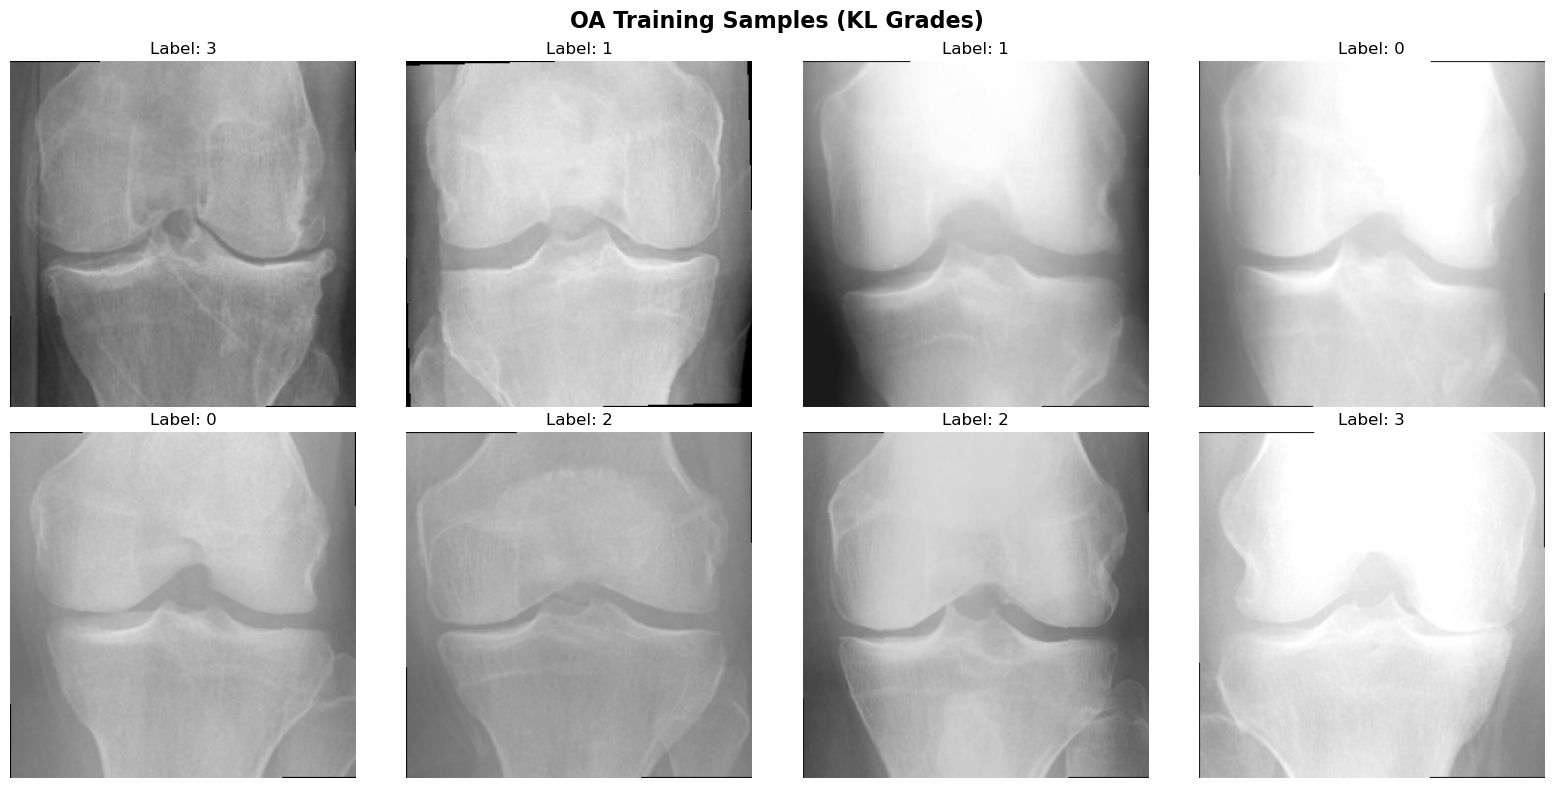

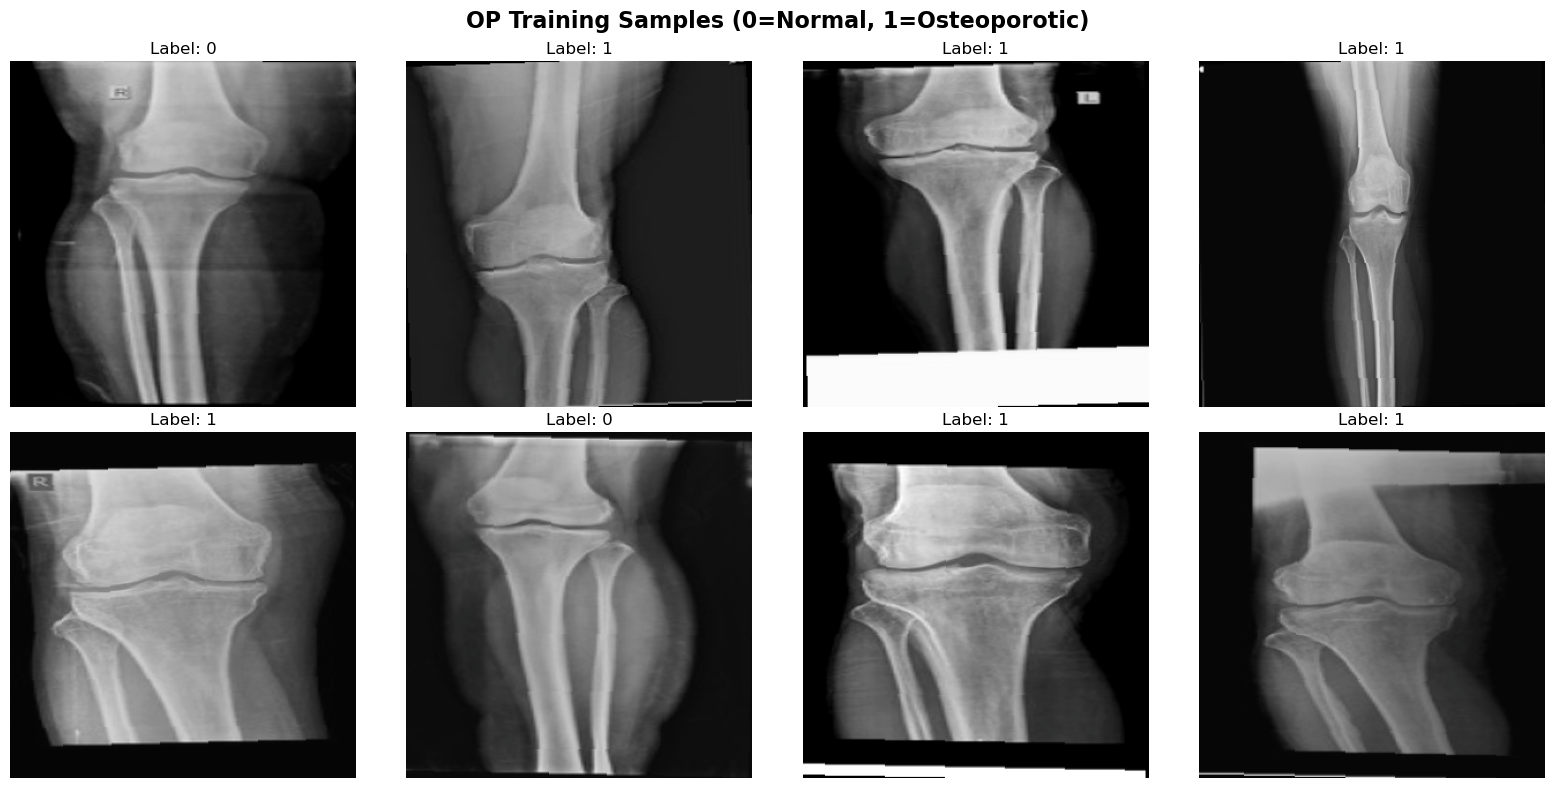

In [25]:
# Visualize sample images
def visualize_samples(dataloader, title, num_samples=8):
    """Visualize sample images from dataloader"""
    images, labels = next(iter(dataloader))
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()
    
    # Denormalize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    for idx in range(min(num_samples, len(images))):
        img = images[idx] * std + mean
        img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        
        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title(f"Label: {labels[idx].item()}", fontsize=12)
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Show OA samples
visualize_samples(oa_train_loader, "OA Training Samples (KL Grades)")

# Show OP samples
visualize_samples(op_train_loader, "OP Training Samples (0=Normal, 1=Osteoporotic)")

## Phase 2: Model Architecture Components

In [26]:
class ChannelAttention(nn.Module):
    """Channel attention module from CBAM"""
    
    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        b, c, _, _ = x.size()
        
        avg_out = self.fc(self.avg_pool(x).view(b, c))
        max_out = self.fc(self.max_pool(x).view(b, c))
        
        out = self.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * out.expand_as(x)


class SpatialAttention(nn.Module):
    """Spatial attention module from CBAM"""
    
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        
        out = torch.cat([avg_out, max_out], dim=1)
        out = self.sigmoid(self.conv(out))
        
        return x * out


class CBAM(nn.Module):
    """Convolutional Block Attention Module"""
    
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super(CBAM, self).__init__()
        self.channel_attention = ChannelAttention(in_channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)
    
    def forward(self, x):
        x = self.channel_attention(x)
        x = self.spatial_attention(x)
        return x

print("✓ CBAM attention modules defined")

✓ CBAM attention modules defined


In [27]:
class TeacherModel(nn.Module):
    """Domain-specific teacher model for single task"""
    
    def __init__(self, num_classes, task_type='classification'):
        super(TeacherModel, self).__init__()
        self.task_type = task_type
        
        # Load pre-trained EfficientNet-B3
        self.backbone = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)
        
        # Get feature dimension
        in_features = self.backbone.classifier[1].in_features
        
        # Replace classifier
        if task_type == 'multiclass':  # OA
            self.backbone.classifier = nn.Sequential(
                nn.Dropout(p=0.3),
                nn.Linear(in_features, 512),
                nn.ReLU(),
                nn.Dropout(p=0.2),
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Linear(256, num_classes)
            )
        else:  # OP - binary
            self.backbone.classifier = nn.Sequential(
                nn.Dropout(p=0.3),
                nn.Linear(in_features, 512),
                nn.ReLU(),
                nn.Dropout(p=0.2),
                nn.Linear(512, 256),
                nn.ReLU(),
                nn.Linear(256, num_classes)
            )
    
    def forward(self, x):
        return self.backbone(x)

print("✓ Teacher model defined")

✓ Teacher model defined


In [28]:
class StudentMultiTaskModel(nn.Module):
    """Multi-task student model with shared backbone and task-specific heads"""
    
    def __init__(self, num_oa_classes=5, num_op_classes=1):
        super(StudentMultiTaskModel, self).__init__()
        
        # Shared backbone (EfficientNet-B3)
        self.backbone = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)
        
        # Remove the classifier to get features
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        
        # CBAM attention module
        self.cbam = CBAM(in_channels=1536)  # EfficientNet-B3 last conv channels
        
        # Global average pooling
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        # OA Task Head (5-class classification)
        self.oa_head = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_oa_classes)
        )
        
        # OP Task Head (binary classification)
        self.op_head = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_op_classes)
        )
    
    def forward(self, x, return_features=False):
        # Extract features from backbone
        features = self.backbone.features(x)
        
        # Apply CBAM attention
        features_attended = self.cbam(features)
        
        # Global pooling
        pooled = self.global_pool(features_attended)
        pooled = pooled.view(pooled.size(0), -1)
        
        # Task-specific predictions
        oa_logits = self.oa_head(pooled)
        op_logits = self.op_head(pooled)
        
        if return_features:
            return oa_logits, op_logits, pooled
        
        return oa_logits, op_logits

print("✓ Student multi-task model defined")

✓ Student multi-task model defined


## Phase 3: Loss Functions and Metrics

In [29]:
class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance"""
    
    def __init__(self, alpha=0.25, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        BCE_loss = F.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        F_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        return F_loss.mean()


class WeightedCrossEntropyLoss(nn.Module):
    """Weighted CE for multi-class with class imbalance"""
    
    def __init__(self, class_weights=None):
        super(WeightedCrossEntropyLoss, self).__init__()
        self.class_weights = class_weights
    
    def forward(self, inputs, targets):
        if self.class_weights is not None:
            return F.cross_entropy(inputs, targets, weight=self.class_weights)
        return F.cross_entropy(inputs, targets)


class KnowledgeDistillationLoss(nn.Module):
    """KL Divergence loss for knowledge distillation"""
    
    def __init__(self, temperature=3.0):
        super(KnowledgeDistillationLoss, self).__init__()
        self.temperature = temperature
    
    def forward(self, student_logits, teacher_logits):
        student_soft = F.log_softmax(student_logits / self.temperature, dim=1)
        teacher_soft = F.softmax(teacher_logits / self.temperature, dim=1)
        
        kd_loss = F.kl_div(student_soft, teacher_soft, reduction='batchmean')
        kd_loss = kd_loss * (self.temperature ** 2)
        
        return kd_loss

print("✓ Loss functions defined")

✓ Loss functions defined


In [30]:
def quadratic_weighted_kappa(y_true, y_pred, num_classes=5):
    """Calculate Quadratic Weighted Kappa for ordinal classification"""
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')


def calculate_metrics(y_true, y_pred, y_prob=None, task='multiclass'):
    """Calculate comprehensive metrics for evaluation"""
    metrics = {}
    
    metrics['accuracy'] = accuracy_score(y_true, y_pred)
    
    if task == 'multiclass':
        metrics['qwk'] = quadratic_weighted_kappa(y_true, y_pred)
        metrics['macro_f1'] = f1_score(y_true, y_pred, average='macro')
    else:  # binary
        metrics['f1'] = f1_score(y_true, y_pred)
        if y_prob is not None:
            metrics['auc'] = roc_auc_score(y_true, y_prob)
    
    return metrics

print("✓ Metric functions defined")

✓ Metric functions defined


## Phase 4: PCGrad Implementation

In [31]:
class PCGrad:
    """
    Projecting Conflicting Gradients (PCGrad)
    Resolves gradient conflicts in multi-task learning
    """
    
    def __init__(self, optimizer):
        self.optimizer = optimizer
    
    def _project_conflicting(self, grads):
        """Project conflicting gradients"""
        if not isinstance(grads, list):
            grads = [grads]
        
        if len(grads) <= 1:
            return grads
        
        # Flatten gradients
        grads_flat = []
        shapes = []
        
        for grad in grads:
            shape = []
            flat = []
            for g in grad:
                if g is not None:
                    shape.append(g.shape)
                    flat.append(g.flatten())
                else:
                    shape.append(None)
            
            if flat:
                grads_flat.append(torch.cat(flat))
                shapes.append(shape)
        
        if len(grads_flat) != 2:
            return grads
        
        # Calculate dot product
        g1, g2 = grads_flat[0], grads_flat[1]
        dot_product = torch.dot(g1, g2)
        
        # If conflict detected (negative dot product)
        if dot_product < 0:
            g1_proj = g1 - (dot_product / (torch.norm(g2) ** 2 + 1e-8)) * g2
            g2_proj = g2 - (dot_product / (torch.norm(g1) ** 2 + 1e-8)) * g1
            
            # Reconstruct gradients
            grads_projected = []
            
            for i, (g_flat, shape) in enumerate([(g1_proj, shapes[0]), (g2_proj, shapes[1])]):
                idx = 0
                grad_reconstructed = []
                
                for s in shape:
                    if s is not None:
                        numel = np.prod(s)
                        grad_reconstructed.append(g_flat[idx:idx+numel].view(s))
                        idx += numel
                    else:
                        grad_reconstructed.append(None)
                
                grads_projected.append(grad_reconstructed)
            
            return grads_projected
        
        return grads
    
    def step(self, losses):
        """Perform optimization step with gradient projection"""
        task_grads = []
        
        # Compute gradients for each task
        for i, loss in enumerate(losses):
            self.optimizer.zero_grad()
            loss.backward(retain_graph=(i < len(losses) - 1))
            
            grads = []
            for param in self.optimizer.param_groups[0]['params']:
                if param.grad is not None:
                    grads.append(param.grad.clone())
                else:
                    grads.append(None)
            task_grads.append(grads)
        
        # Project conflicting gradients
        projected_grads = self._project_conflicting(task_grads)
        
        # Average projected gradients
        self.optimizer.zero_grad()
        
        for param_idx, param in enumerate(self.optimizer.param_groups[0]['params']):
            grad_sum = None
            count = 0
            
            for task_grad in projected_grads:
                if task_grad[param_idx] is not None:
                    if grad_sum is None:
                        grad_sum = task_grad[param_idx].clone()
                    else:
                        grad_sum += task_grad[param_idx]
                    count += 1
            
            if grad_sum is not None and count > 0:
                param.grad = grad_sum / count
        
        self.optimizer.step()

print("✓ PCGrad optimizer defined")

✓ PCGrad optimizer defined


## Phase 5: Training Functions

*(Same training functions as before - they work with any dataset structure)*

In [32]:
def train_teacher_model(model, train_loader, val_loader, task_name='OA', num_epochs=30):
    """Train a domain-specific teacher model"""
    model = model.to(device)
    
    # Loss function
    if task_name == 'OA':
        criterion = nn.CrossEntropyLoss()
    else:
        criterion = nn.BCEWithLogitsLoss()
    
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    
    print(f"\n{'='*60}")
    print(f"Training Teacher Model: {task_name}")
    print(f"{'='*60}")
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for images, labels in train_pbar:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            
            if task_name == 'OP':
                labels = labels.float().unsqueeze(1)
            
            loss = criterion(outputs, labels)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_pbar.set_postfix({'loss': loss.item()})
        
        avg_train_loss = train_loss / len(train_loader)
        
        # Validation
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                
                outputs = model(images)
                
                if task_name == 'OP':
                    labels_loss = labels.float().unsqueeze(1)
                    loss = criterion(outputs, labels_loss)
                    preds = (torch.sigmoid(outputs) > 0.5).long().squeeze()
                else:
                    loss = criterion(outputs, labels)
                    preds = outputs.argmax(dim=1)
                
                val_loss += loss.item()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(all_labels, all_preds)
        
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        
        scheduler.step()
        
        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.4f}")
        
        # Save best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            
            checkpoint_path = os.path.join(
                CONFIG['checkpoint_dir'], 'teachers', f'teacher_{task_name.lower()}_best.pth'
            )
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': avg_val_loss,
                'val_acc': val_acc,
            }, checkpoint_path)
            print(f"✓ Saved best model (val_loss: {avg_val_loss:.4f})")
        else:
            patience_counter += 1
        
        if patience_counter >= CONFIG['early_stopping_patience']:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    return model, history

print("✓ Teacher training function defined")

✓ Teacher training function defined


In [33]:
class PCGrad:
    """
    Projecting Conflicting Gradients (PCGrad)
    Resolves gradient conflicts in multi-task learning
    """

    def __init__(self, optimizer):
        self.optimizer = optimizer

    def _project_conflicting(self, grads):
        """Project conflicting gradients"""
        if not isinstance(grads, list):
            grads = [grads]

        if len(grads) <= 1:
            return grads

        # Flatten gradients
        grads_flat = []
        shapes = []

        for grad in grads:
            shape = []
            flat = []
            for g in grad:
                if g is not None:
                    shape.append(g.shape)
                    flat.append(g.flatten())
                else:
                    shape.append(None)

            if flat:
                grads_flat.append(torch.cat(flat))
                shapes.append(shape)

        if len(grads_flat) != 2:
            return grads

        # Calculate dot product
        g1, g2 = grads_flat[0], grads_flat[1]
        dot_product = torch.dot(g1, g2)

        # If conflict detected (negative dot product)
        if dot_product < 0:
            g1_proj = g1 - (dot_product / (torch.norm(g2) ** 2 + 1e-8)) * g2
            g2_proj = g2 - (dot_product / (torch.norm(g1) ** 2 + 1e-8)) * g1

            # Reconstruct gradients
            grads_projected = []
            for g_flat, shape in [(g1_proj, shapes[0]), (g2_proj, shapes[1])]:
                idx = 0
                grad_reconstructed = []

                for s in shape:
                    if s is not None:
                        numel = np.prod(s)
                        grad_reconstructed.append(g_flat[idx:idx + numel].view(s))
                        idx += numel
                    else:
                        grad_reconstructed.append(None)

                grads_projected.append(grad_reconstructed)

            return grads_projected

        return grads

    def step(self, losses):
        """Perform optimization step with gradient projection"""
        task_grads = []

        # Compute gradients for each task
        for i, loss in enumerate(losses):
            self.optimizer.zero_grad()
            loss.backward(retain_graph=(i < len(losses) - 1))

            grads = []
            for param in self.optimizer.param_groups[0]['params']:
                if param.grad is not None:
                    grads.append(param.grad.detach().clone())
                else:
                    # Keep parameter alignment across tasks for valid dot products.
                    grads.append(torch.zeros_like(param))
            task_grads.append(grads)

        # Project conflicting gradients
        projected_grads = self._project_conflicting(task_grads)

        # Average projected gradients
        self.optimizer.zero_grad()

        for param_idx, param in enumerate(self.optimizer.param_groups[0]['params']):
            grad_sum = None
            count = 0

            for task_grad in projected_grads:
                if task_grad[param_idx] is not None:
                    if grad_sum is None:
                        grad_sum = task_grad[param_idx].clone()
                    else:
                        grad_sum += task_grad[param_idx]
                    count += 1

            if grad_sum is not None and count > 0:
                param.grad = grad_sum / count

        self.optimizer.step()


print("✓ PCGrad optimizer defined")

✓ PCGrad optimizer defined


In [34]:
def train_student_with_kd(
    student_model, teacher_oa, teacher_op,
    oa_train_loader, op_train_loader,
    oa_val_loader, op_val_loader,
    num_epochs=50
):
    """Train student model with knowledge distillation and PCGrad"""
    student_model = student_model.to(device)
    teacher_oa = teacher_oa.to(device).eval()
    teacher_op = teacher_op.to(device).eval()

    for param in teacher_oa.parameters():
        param.requires_grad = False
    for param in teacher_op.parameters():
        param.requires_grad = False

    criterion_oa = WeightedCrossEntropyLoss()
    criterion_op = FocalLoss()
    kd_criterion = KnowledgeDistillationLoss(temperature=CONFIG['temperature'])

    optimizer = optim.AdamW(
        student_model.parameters(),
        lr=CONFIG['learning_rate'],
        weight_decay=CONFIG['weight_decay']
    )

    pcgrad_optimizer = PCGrad(optimizer)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    history = {
        'train_loss_oa': [], 'train_loss_op': [],
        'val_loss_oa': [], 'val_loss_op': [],
        'val_acc_oa': [], 'val_acc_op': [],
        'val_qwk_oa': [], 'val_auc_op': [],
    }

    best_combined_metric = -float('inf')

    print(f"\n{'='*60}")
    print("Training Student Model with Knowledge Distillation")
    print(f"{'='*60}")

    for epoch in range(num_epochs):
        student_model.train()

        oa_iter = iter(oa_train_loader)
        op_iter = iter(op_train_loader)

        epoch_loss_oa = 0.0
        epoch_loss_op = 0.0

        num_batches = min(len(oa_train_loader), len(op_train_loader))
        pbar = tqdm(range(num_batches), desc=f"Epoch {epoch+1}/{num_epochs}")

        for _ in pbar:
            try:
                oa_images, oa_labels = next(oa_iter)
            except StopIteration:
                oa_iter = iter(oa_train_loader)
                oa_images, oa_labels = next(oa_iter)

            try:
                op_images, op_labels = next(op_iter)
            except StopIteration:
                op_iter = iter(op_train_loader)
                op_images, op_labels = next(op_iter)

            oa_images = oa_images.to(device)
            oa_labels = oa_labels.to(device)
            op_images = op_images.to(device)
            op_labels = op_labels.to(device).float().unsqueeze(1)

            # OA task
            oa_student_logits, _ = student_model(oa_images)
            with torch.no_grad():
                oa_teacher_logits = teacher_oa(oa_images)

            loss_oa_ce = criterion_oa(oa_student_logits, oa_labels)
            loss_oa_kd = kd_criterion(oa_student_logits, oa_teacher_logits)
            loss_oa_total = CONFIG['alpha'] * loss_oa_ce + CONFIG['lambda_1'] * loss_oa_kd

            # OP task
            _, op_student_logits = student_model(op_images)
            with torch.no_grad():
                op_teacher_logits = teacher_op(op_images)

            loss_op_focal = criterion_op(op_student_logits, op_labels)

            op_student_probs = torch.sigmoid(op_student_logits / CONFIG['temperature'])
            op_teacher_probs = torch.sigmoid(op_teacher_logits / CONFIG['temperature'])
            loss_op_kd = F.binary_cross_entropy(
                op_student_probs, op_teacher_probs.detach()
            ) * (CONFIG['temperature'] ** 2)

            loss_op_total = CONFIG['beta'] * loss_op_focal + CONFIG['lambda_2'] * loss_op_kd

            # PCGrad step
            pcgrad_optimizer.step([loss_oa_total, loss_op_total])

            epoch_loss_oa += loss_oa_total.item()
            epoch_loss_op += loss_op_total.item()

            pbar.set_postfix({'OA': loss_oa_total.item(), 'OP': loss_op_total.item()})

        avg_train_loss_oa = epoch_loss_oa / num_batches
        avg_train_loss_op = epoch_loss_op / num_batches

        # Validation
        val_metrics = evaluate_student(student_model, oa_val_loader, op_val_loader)

        history['train_loss_oa'].append(avg_train_loss_oa)
        history['train_loss_op'].append(avg_train_loss_op)
        history['val_loss_oa'].append(val_metrics['oa_loss'])
        history['val_loss_op'].append(val_metrics['op_loss'])
        history['val_acc_oa'].append(val_metrics['oa_acc'])
        history['val_acc_op'].append(val_metrics['op_acc'])
        history['val_qwk_oa'].append(val_metrics['oa_qwk'])
        history['val_auc_op'].append(val_metrics['op_auc'])

        scheduler.step()

        # Combined score for best checkpoint tracking
        combined_metric = 0.5 * val_metrics['oa_qwk'] + 0.5 * val_metrics['op_auc']

        print(
            f"Epoch {epoch+1:03d}/{num_epochs} | "
            f"OA Loss: {avg_train_loss_oa:.4f} | OP Loss: {avg_train_loss_op:.4f} | "
            f"OA QWK: {val_metrics['oa_qwk']:.4f} | OP AUC: {val_metrics['op_auc']:.4f}"
        )

        if combined_metric > best_combined_metric:
            best_combined_metric = combined_metric
            checkpoint_path = os.path.join(CONFIG['checkpoint_dir'], 'student', 'student_best.pth')
            torch.save({
                'epoch': epoch,
                'model_state_dict': student_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_metrics': val_metrics,
                'combined_metric': combined_metric,
            }, checkpoint_path)
            print(f"✓ Saved best student model (combined metric: {combined_metric:.4f})")

    return student_model, history


print("✓ Student training function defined")

✓ Student training function defined


In [35]:
def evaluate_student(model, oa_val_loader, op_val_loader):
    """Evaluate student model on both tasks"""
    model.eval()
    
    # OA evaluation
    oa_preds, oa_labels = [], []
    oa_loss = 0.0
    criterion_oa = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for images, labels in oa_val_loader:
            images, labels = images.to(device), labels.to(device)
            oa_logits, _ = model(images)
            loss = criterion_oa(oa_logits, labels)
            oa_loss += loss.item()
            
            preds = oa_logits.argmax(dim=1)
            oa_preds.extend(preds.cpu().numpy())
            oa_labels.extend(labels.cpu().numpy())
    
    oa_metrics = calculate_metrics(oa_labels, oa_preds, task='multiclass')
    
    # OP evaluation
    op_preds, op_labels, op_probs = [], [], []
    op_loss = 0.0
    criterion_op = nn.BCEWithLogitsLoss()
    
    with torch.no_grad():
        for images, labels in op_val_loader:
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            _, op_logits = model(images)
            loss = criterion_op(op_logits, labels)
            op_loss += loss.item()
            
            probs = torch.sigmoid(op_logits).squeeze()
            preds = (probs > 0.5).long()
            
            op_preds.extend(preds.cpu().numpy())
            op_probs.extend(probs.cpu().numpy())
            op_labels.extend(labels.squeeze().cpu().numpy())
    
    op_metrics = calculate_metrics(op_labels, op_preds, y_prob=op_probs, task='binary')
    
    return {
        'oa_loss': oa_loss / len(oa_val_loader),
        'oa_acc': oa_metrics['accuracy'],
        'oa_qwk': oa_metrics['qwk'],
        'op_loss': op_loss / len(op_val_loader),
        'op_acc': op_metrics['accuracy'],
        'op_auc': op_metrics['auc'],
        'op_f1': op_metrics['f1'],
    }

print("✓ Evaluation function defined")

✓ Evaluation function defined


## Phase 6: Visualization Functions

*(Same as before)*

In [36]:
def plot_training_history(history, save_path=None):
    """Plot training history"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    axes[0, 0].plot(history['train_loss_oa'], label='Train')
    axes[0, 0].plot(history['val_loss_oa'], label='Val')
    axes[0, 0].set_title('OA Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(history['train_loss_op'], label='Train')
    axes[0, 1].plot(history['val_loss_op'], label='Val')
    axes[0, 1].set_title('OP Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[0, 2].plot(history['val_acc_oa'])
    axes[0, 2].set_title('OA Accuracy')
    axes[0, 2].grid(True, alpha=0.3)
    
    axes[1, 0].plot(history['val_acc_op'])
    axes[1, 0].set_title('OP Accuracy')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(history['val_qwk_oa'])
    axes[1, 1].set_title('OA QWK')
    axes[1, 1].grid(True, alpha=0.3)
    
    axes[1, 2].plot(history['val_auc_op'])
    axes[1, 2].set_title('OP AUC')
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


def plot_confusion_matrix(y_true, y_pred, labels, title, save_path=None):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(title)
    plt.ylabel('True')
    plt.xlabel('Predicted')
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

print("✓ Visualization functions defined")

✓ Visualization functions defined


## Phase 7: Main Training Pipeline

In [21]:
# STEP 1: Train OA Teacher
print("\nStep 1: Training OA Teacher...")
teacher_oa = TeacherModel(num_classes=5, task_type='multiclass')
teacher_oa, oa_history = train_teacher_model(
    teacher_oa, oa_train_loader, oa_val_loader,
    task_name='OA', num_epochs=30
)
print("✓ OA Teacher trained")


Step 1: Training OA Teacher...
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /Users/masumahmed/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████████████████████████████████████████████████████████████████████████████████████| 47.2M/47.2M [00:04<00:00, 11.7MB/s]



Training Teacher Model: OA


Epoch 1/30 [Train]:   0%|          | 0/723 [00:00<?, ?it/s]

Epoch 1: Train Loss=1.1257, Val Loss=0.9794, Val Acc=0.5823
✓ Saved best model (val_loss: 0.9794)


...

Epoch 12: Train Loss=0.3256, Val Loss=1.1293, Val Acc=0.6525


Epoch 13/30 [Train]:   0%|          | 0/723 [00:00<?, ?it/s]

Epoch 13: Train Loss=0.2599, Val Loss=1.2548, Val Acc=0.6792


Epoch 14/30 [Train]:   0%|          | 0/723 [00:00<?, ?it/s]

Epoch 14: Train Loss=0.2165, Val Loss=1.2789, Val Acc=0.6477
Early stopping at epoch 14
✓ OA Teacher trained


In [22]:
# STEP 2: Train OP Teacher
print("\nStep 2: Training OP Teacher...")
teacher_op = TeacherModel(num_classes=1, task_type='binary')
teacher_op, op_history = train_teacher_model(
    teacher_op, op_train_loader, op_val_loader,
    task_name='OP', num_epochs=30
)
print("✓ OP Teacher trained")


Step 2: Training OP Teacher...

Training Teacher Model: OP


Epoch 1/30 [Train]:   0%|          | 0/138 [00:00<?, ?it/s]

Epoch 1: Train Loss=0.5934, Val Loss=0.4345, Val Acc=0.8043
✓ Saved best model (val_loss: 0.4345)


Epoch 2/30 [Train]:   0%|          | 0/138 [00:00<?, ?it/s]

Epoch 2: Train Loss=0.4537, Val Loss=0.3513, Val Acc=0.8511
✓ Saved best model (val_loss: 0.3513)


...

Epoch 15: Train Loss=0.1011, Val Loss=0.2695, Val Acc=0.9404


Epoch 16/30 [Train]:   0%|          | 0/138 [00:00<?, ?it/s]

Epoch 16: Train Loss=0.0902, Val Loss=0.3083, Val Acc=0.9404


Epoch 17/30 [Train]:   0%|          | 0/138 [00:00<?, ?it/s]

Epoch 17: Train Loss=0.0754, Val Loss=0.2922, Val Acc=0.9404
Early stopping at epoch 17
✓ OP Teacher trained


In [37]:
# STEP 3: Load Best Teachers
print("\nStep 3: Loading best teachers...")

oa_checkpoint = torch.load(os.path.join(CONFIG['checkpoint_dir'], 'teachers', 'teacher_oa_best.pth'))
teacher_oa = TeacherModel(num_classes=5, task_type='multiclass')
teacher_oa.load_state_dict(oa_checkpoint['model_state_dict'])
teacher_oa = teacher_oa.to(device).eval()

op_checkpoint = torch.load(os.path.join(CONFIG['checkpoint_dir'], 'teachers', 'teacher_op_best.pth'))
teacher_op = TeacherModel(num_classes=1, task_type='binary')
teacher_op.load_state_dict(op_checkpoint['model_state_dict'])
teacher_op = teacher_op.to(device).eval()

print(f"✓ OA Teacher Val Acc: {oa_checkpoint['val_acc']:.4f}")
print(f"✓ OP Teacher Val Acc: {op_checkpoint['val_acc']:.4f}")


Step 3: Loading best teachers...
✓ OA Teacher Val Acc: 0.6683
✓ OP Teacher Val Acc: 0.9404


In [38]:
# STEP 4: Train Student
print("\nStep 4: Training student...")
student_model = StudentMultiTaskModel(
    num_oa_classes=CONFIG['num_oa_classes'],
    num_op_classes=CONFIG['num_op_classes']
)

student_model, history = train_student_with_kd(
    student_model, teacher_oa, teacher_op,
    oa_train_loader, op_train_loader,
    oa_val_loader, op_val_loader,
    num_epochs=CONFIG['num_epochs']
)
print("✓ Student trained")


Step 4: Training student...

Training Student Model with Knowledge Distillation


Epoch 1/50:   0%|          | 0/138 [00:00<?, ?it/s]

Epoch 001/50 | OA Loss: 0.8686 | OP Loss: 1.2416 | OA QWK: 0.0000 | OP AUC: 0.7912
✓ Saved best student model (combined metric: 0.3956)


Epoch 2/50:   0%|          | 0/138 [00:00<?, ?it/s]

Epoch 002/50 | OA Loss: 0.6805 | OP Loss: 1.1478 | OA QWK: 0.4177 | OP AUC: 0.8335
✓ Saved best student model (combined metric: 0.6256)


...

Epoch 048/50 | OA Loss: 0.2260 | OP Loss: 0.7782 | OA QWK: 0.7049 | OP AUC: 0.9755


Epoch 49/50:   0%|          | 0/138 [00:00<?, ?it/s]

Epoch 049/50 | OA Loss: 0.2253 | OP Loss: 0.7821 | OA QWK: 0.7006 | OP AUC: 0.9759


Epoch 50/50:   0%|          | 0/138 [00:00<?, ?it/s]

Epoch 050/50 | OA Loss: 0.2421 | OP Loss: 0.7835 | OA QWK: 0.7130 | OP AUC: 0.9764
✓ Student trained


## Phase 8: Evaluation and Results

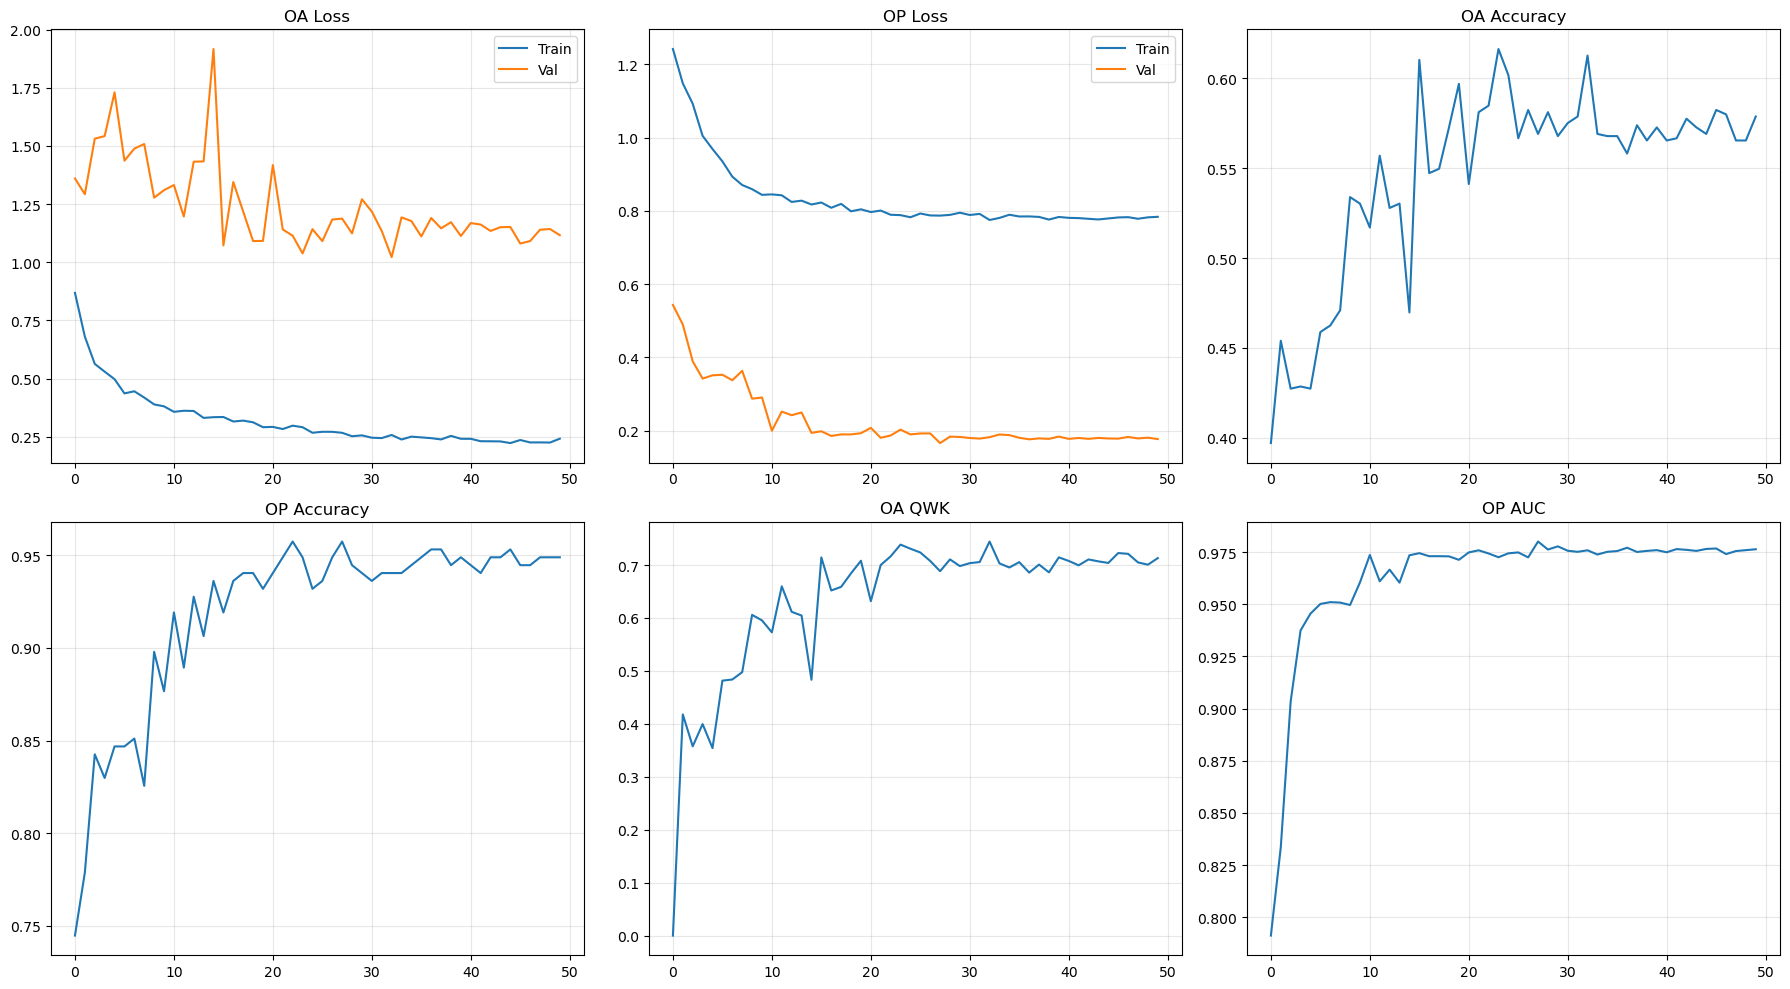

In [39]:
# Plot training history
plot_training_history(
    history,
    save_path=os.path.join(CONFIG['results_dir'], 'plots', 'training_history.png')
)

In [40]:
# Load best model and evaluate
checkpoint = torch.load(os.path.join(CONFIG['checkpoint_dir'], 'student', 'student_best.pth'))
student_model = StudentMultiTaskModel()
student_model.load_state_dict(checkpoint['model_state_dict'])
student_model = student_model.to(device).eval()

print("Best Model Metrics:")
print(json.dumps(checkpoint['val_metrics'], indent=2))

Best Model Metrics:
{
  "oa_loss": 1.0222276072376049,
  "oa_acc": 0.612590799031477,
  "oa_qwk": 0.7443413509839845,
  "op_loss": 0.18197646755725144,
  "op_acc": 0.9404255319148936,
  "op_auc": 0.9758438360133276,
  "op_f1": 0.9401709401709402
}


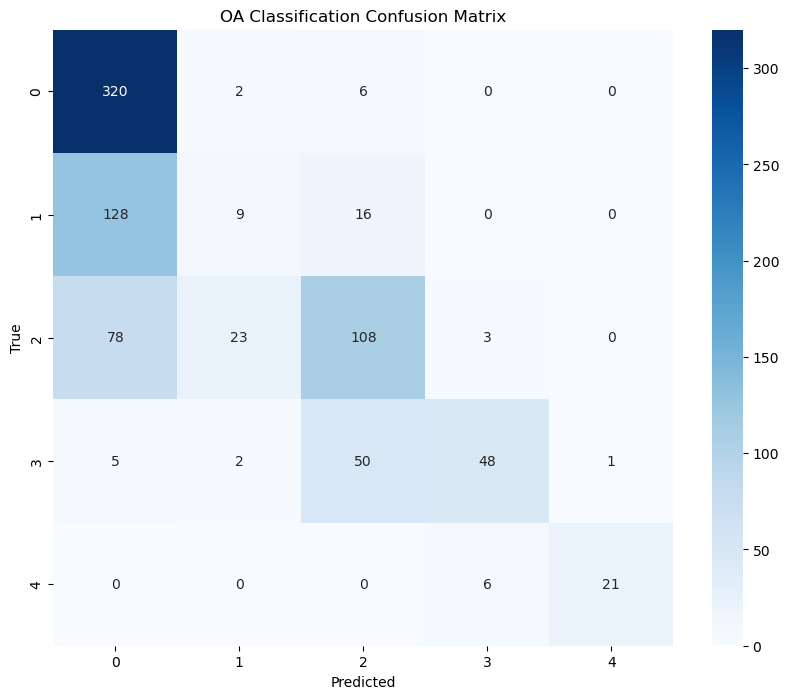

In [41]:
# Generate confusion matrices
oa_preds, oa_labels = [], []
with torch.no_grad():
    for images, labels in oa_val_loader:
        images = images.to(device)
        oa_logits, _ = student_model(images)
        preds = oa_logits.argmax(dim=1)
        oa_preds.extend(preds.cpu().numpy())
        oa_labels.extend(labels.cpu().numpy())

plot_confusion_matrix(
    oa_labels, oa_preds,
    labels=['0', '1', '2', '3', '4'],
    title='OA Classification Confusion Matrix',
    save_path=os.path.join(CONFIG['results_dir'], 'confusion_matrices', 'cm_oa.png')
)

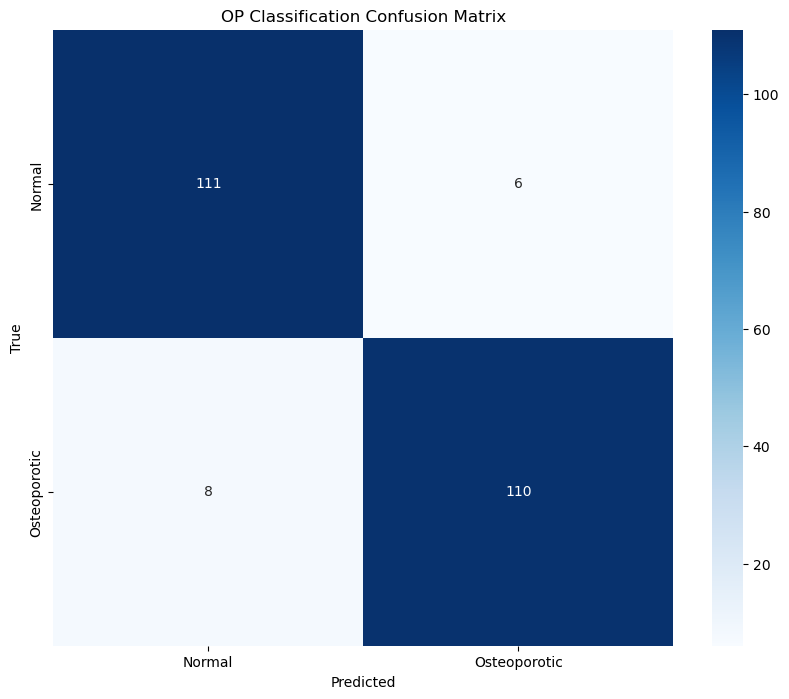

In [42]:
# OP confusion matrix
op_preds, op_labels = [], []
with torch.no_grad():
    for images, labels in op_val_loader:
        images = images.to(device)
        _, op_logits = student_model(images)
        preds = (torch.sigmoid(op_logits) > 0.5).long().squeeze()
        op_preds.extend(preds.cpu().numpy())
        op_labels.extend(labels.cpu().numpy())

plot_confusion_matrix(
    op_labels, op_preds,
    labels=['Normal', 'Osteoporotic'],
    title='OP Classification Confusion Matrix',
    save_path=os.path.join(CONFIG['results_dir'], 'confusion_matrices', 'cm_op.png')
)

In [43]:
# Classification reports
print("\nOA Classification Report:")
print(classification_report(oa_labels, oa_preds, target_names=['KL-0', 'KL-1', 'KL-2', 'KL-3', 'KL-4']))

print("\nOP Classification Report:")
print(classification_report(op_labels, op_preds, target_names=['Normal', 'Osteoporotic']))


OA Classification Report:
              precision    recall  f1-score   support

        KL-0       0.60      0.98      0.75       328
        KL-1       0.25      0.06      0.10       153
        KL-2       0.60      0.51      0.55       212
        KL-3       0.84      0.45      0.59       106
        KL-4       0.95      0.78      0.86        27

    accuracy                           0.61       826
   macro avg       0.65      0.55      0.57       826
weighted avg       0.58      0.61      0.56       826


OP Classification Report:
              precision    recall  f1-score   support

      Normal       0.93      0.95      0.94       117
Osteoporotic       0.95      0.93      0.94       118

    accuracy                           0.94       235
   macro avg       0.94      0.94      0.94       235
weighted avg       0.94      0.94      0.94       235



In [44]:
# Save final results
final_results = {
    'config': CONFIG,
    'best_epoch': int(checkpoint['epoch']),
    'val_metrics': {k: float(v) for k, v in checkpoint['val_metrics'].items()},
}

with open(os.path.join(CONFIG['results_dir'], 'final_results.json'), 'w') as f:
    json.dump(final_results, f, indent=2)

print("\n✓ Training Complete!")
print(f"Results saved to {CONFIG['results_dir']}")


✓ Training Complete!
Results saved to ./results


## Phase 9: Inference

Use the trained model on new images

In [45]:
def predict_single_image(model, image_path):
    """Predict on a single image"""
    model.eval()
    
    image = Image.open(image_path).convert('RGB')
    image_tensor = val_transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        oa_logits, op_logits = model(image_tensor)
        
        oa_probs = F.softmax(oa_logits, dim=1).squeeze()
        oa_pred = oa_logits.argmax(dim=1).item()
        oa_confidence = oa_probs[oa_pred].item()
        
        op_prob = torch.sigmoid(op_logits).item()
        op_pred = 1 if op_prob > 0.5 else 0
        op_confidence = op_prob if op_pred == 1 else (1 - op_prob)
    
    return {
        'oa_grade': oa_pred,
        'oa_confidence': oa_confidence,
        'op_status': 'Osteoporotic' if op_pred == 1 else 'Normal',
        'op_confidence': op_confidence,
    }

print("✓ Inference function ready")

✓ Inference function ready


## Phase 9: Inference, Testing, and Advanced Analysis

EVALUATING ON TEST SET

[1/2] Evaluating OA (Osteoarthritis) task...


OA Test:   0%|          | 0/207 [00:00<?, ?it/s]


✓ OA Test Results:
  Loss: 0.9559
  Accuracy: 0.6262
  QWK: 0.7508
  Macro F1: 0.5761

[2/2] Evaluating OP (Osteoporosis) task...


OP Test:   0%|          | 0/30 [00:00<?, ?it/s]


✓ OP Test Results:
  Loss: 0.2151
  Accuracy: 0.9241
  AUC-ROC: 0.9707
  F1-Score: 0.9244



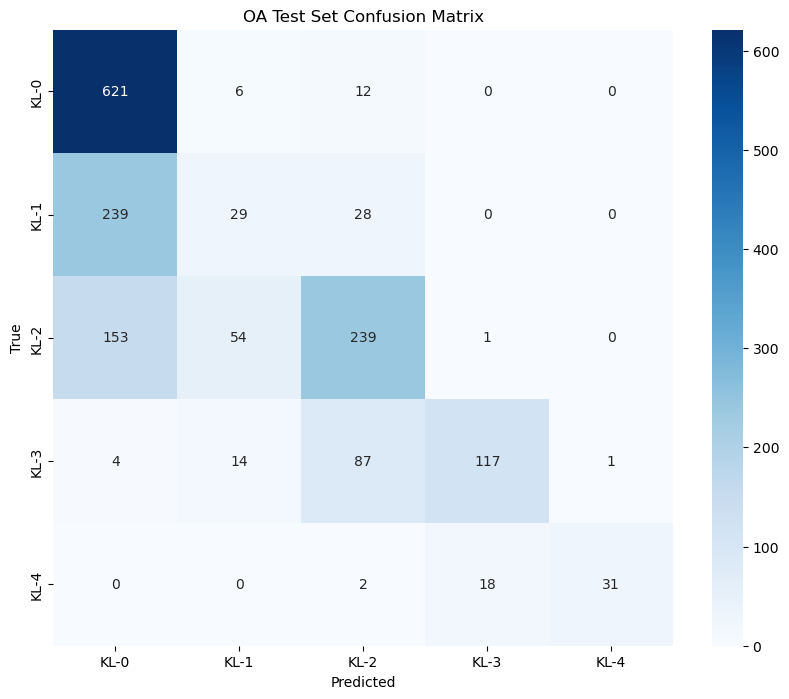

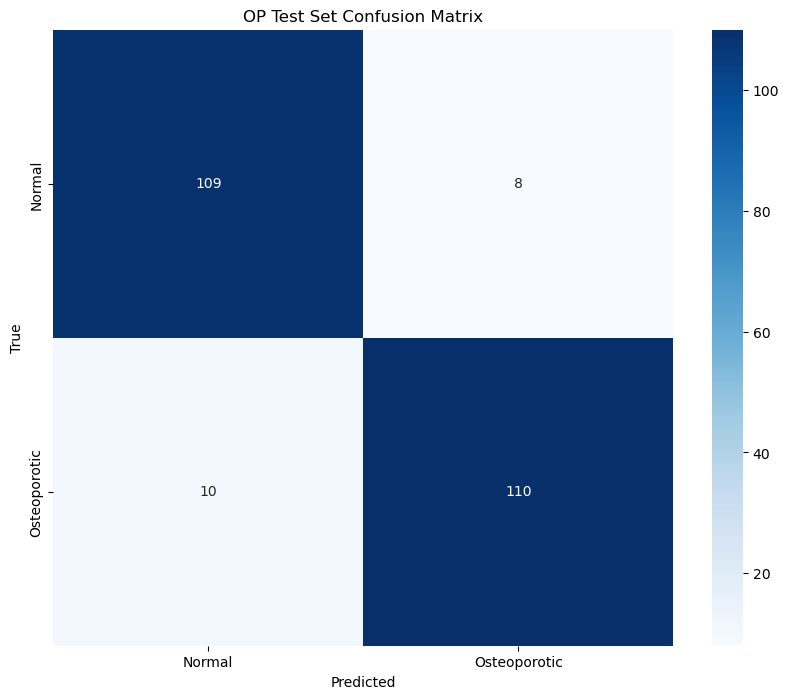


DETAILED TEST SET CLASSIFICATION REPORTS

OA (Osteoarthritis) Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

        KL-0      0.611     0.972     0.750       639
        KL-1      0.282     0.098     0.145       296
        KL-2      0.649     0.535     0.587       447
        KL-3      0.860     0.525     0.652       223
        KL-4      0.969     0.608     0.747        51

    accuracy                          0.626      1656
   macro avg      0.674     0.547     0.576      1656
weighted avg      0.607     0.626     0.584      1656


OP (Osteoporosis) Classification Report:
------------------------------------------------------------
              precision    recall  f1-score   support

      Normal      0.916     0.932     0.924       117
Osteoporotic      0.932     0.917     0.924       120

    accuracy                          0.924       237
   macro avg      0.924     0.924     0.924

In [47]:
def evaluate_on_test_set(model, oa_test_loader, op_test_loader):
    """Comprehensive evaluation on test set"""
    model.eval()
    
    print("="*60)
    print("EVALUATING ON TEST SET")
    print("="*60)
    
    # OA Test Evaluation
    print("\n[1/2] Evaluating OA (Osteoarthritis) task...")
    oa_preds = []
    oa_labels = []
    oa_probs_all = []
    oa_loss = 0.0
    
    criterion_oa = nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for images, labels in tqdm(oa_test_loader, desc="OA Test"):
            images = images.to(device)
            labels = labels.to(device)
            
            oa_logits, _ = model(images)
            loss = criterion_oa(oa_logits, labels)
            oa_loss += loss.item()
            
            probs = F.softmax(oa_logits, dim=1)
            preds = oa_logits.argmax(dim=1)
            
            oa_preds.extend(preds.cpu().numpy())
            oa_labels.extend(labels.cpu().numpy())
            oa_probs_all.extend(probs.cpu().numpy())
    
    oa_metrics = calculate_metrics(oa_labels, oa_preds, task='multiclass')
    
    print(f"\n✓ OA Test Results:")
    print(f"  Loss: {oa_loss / len(oa_test_loader):.4f}")
    print(f"  Accuracy: {oa_metrics['accuracy']:.4f}")
    print(f"  QWK: {oa_metrics['qwk']:.4f}")
    print(f"  Macro F1: {oa_metrics['macro_f1']:.4f}")
    
    # OP Test Evaluation
    print("\n[2/2] Evaluating OP (Osteoporosis) task...")
    op_preds = []
    op_labels = []
    op_probs = []
    op_loss = 0.0
    
    criterion_op = nn.BCEWithLogitsLoss()
    
    with torch.no_grad():
        for images, labels in tqdm(op_test_loader, desc="OP Test"):
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)
            
            _, op_logits = model(images)
            loss = criterion_op(op_logits, labels)
            op_loss += loss.item()
            
            probs = torch.sigmoid(op_logits).squeeze()
            preds = (probs > 0.5).long()
            
            op_preds.extend(preds.cpu().numpy())
            op_probs.extend(probs.cpu().numpy())
            op_labels.extend(labels.squeeze().cpu().numpy())
    
    op_metrics = calculate_metrics(op_labels, op_preds, y_prob=op_probs, task='binary')
    
    print(f"\n✓ OP Test Results:")
    print(f"  Loss: {op_loss / len(op_test_loader):.4f}")
    print(f"  Accuracy: {op_metrics['accuracy']:.4f}")
    print(f"  AUC-ROC: {op_metrics['auc']:.4f}")
    print(f"  F1-Score: {op_metrics['f1']:.4f}")
    
    print("\n" + "="*60)
    
    return {
        'oa': {
            'labels': oa_labels,
            'preds': oa_preds,
            'probs': np.array(oa_probs_all),
            'metrics': oa_metrics
        },
        'op': {
            'labels': op_labels,
            'preds': op_preds,
            'probs': np.array(op_probs),
            'metrics': op_metrics
        }
    }

# Run test evaluation
test_results = evaluate_on_test_set(student_model, oa_test_loader, op_test_loader)

# Plot confusion matrices
plot_confusion_matrix(
    test_results['oa']['labels'],
    test_results['oa']['preds'],
    labels=['KL-0', 'KL-1', 'KL-2', 'KL-3', 'KL-4'],
    title='OA Test Set Confusion Matrix',
    save_path=os.path.join(CONFIG['results_dir'], 'confusion_matrices', 'cm_oa_test.png')
)

plot_confusion_matrix(
    test_results['op']['labels'],
    test_results['op']['preds'],
    labels=['Normal', 'Osteoporotic'],
    title='OP Test Set Confusion Matrix',
    save_path=os.path.join(CONFIG['results_dir'], 'confusion_matrices', 'cm_op_test.png')
)

# Print classification reports
print("\n" + "="*60)
print("DETAILED TEST SET CLASSIFICATION REPORTS")
print("="*60)

print("\nOA (Osteoarthritis) Classification Report:")
print("-" * 60)
print(classification_report(
    test_results['oa']['labels'],
    test_results['oa']['preds'],
    target_names=['KL-0', 'KL-1', 'KL-2', 'KL-3', 'KL-4'],
    digits=3
))

print("\nOP (Osteoporosis) Classification Report:")
print("-" * 60)
print(classification_report(
    test_results['op']['labels'],
    test_results['op']['preds'],
    target_names=['Normal', 'Osteoporotic'],
    digits=3
))

✓ ROC curves saved to ./results/plots/roc_curves.png


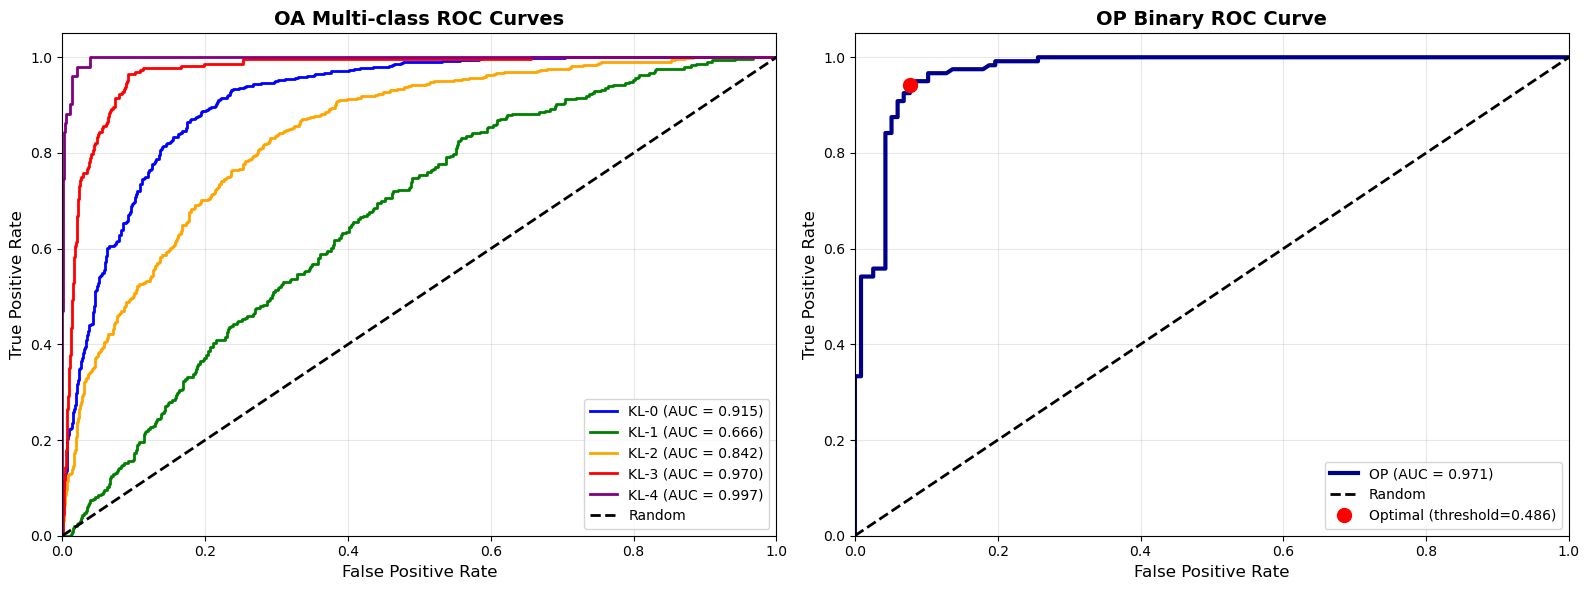


Optimal OP threshold: 0.4865
(Default threshold is 0.5)

ERROR ANALYSIS: OA

Total errors: 619/1656 (37.38%)

Most Common Confusion Patterns:
  True: KL-1 → Predicted: KL-0: 239 times
  True: KL-2 → Predicted: KL-0: 153 times
  True: KL-3 → Predicted: KL-2: 87 times
  True: KL-2 → Predicted: KL-1: 54 times
  True: KL-1 → Predicted: KL-2: 28 times
  True: KL-4 → Predicted: KL-3: 18 times
  True: KL-3 → Predicted: KL-1: 14 times
  True: KL-0 → Predicted: KL-2: 12 times
  True: KL-0 → Predicted: KL-1: 6 times
  True: KL-3 → Predicted: KL-0: 4 times

Off-by-one errors: 434/619 (70.1%)
(Predicting adjacent grade, e.g., KL-2 instead of KL-1)

Low confidence errors (<0.6): 289/619
High confidence errors (≥0.6): 330/619

ERROR ANALYSIS: OP

Total errors: 18/237 (7.59%)

False Positives (Normal → Osteoporotic): 8
False Negatives (Osteoporotic → Normal): 10

False Positive avg confidence: 0.871
False Negative avg confidence: 0.649

Low confidence errors (<0.6): 6/18
High confidence errors (≥0.6

In [48]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_roc_curves(test_results, save_dir):
    """Plot ROC curves for both tasks"""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # OA ROC Curve (one-vs-rest for multiclass)
    oa_labels_bin = label_binarize(
        test_results['oa']['labels'],
        classes=[0, 1, 2, 3, 4]
    )
    oa_probs = test_results['oa']['probs']
    
    colors = ['blue', 'green', 'orange', 'red', 'purple']
    
    for i, (color, grade) in enumerate(zip(colors, ['KL-0', 'KL-1', 'KL-2', 'KL-3', 'KL-4'])):
        fpr, tpr, _ = roc_curve(oa_labels_bin[:, i], oa_probs[:, i])
        roc_auc = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, color=color, lw=2,
                    label=f'{grade} (AUC = {roc_auc:.3f})')
    
    axes[0].plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate', fontsize=12)
    axes[0].set_ylabel('True Positive Rate', fontsize=12)
    axes[0].set_title('OA Multi-class ROC Curves', fontsize=14, fontweight='bold')
    axes[0].legend(loc="lower right", fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # OP ROC Curve (binary)
    fpr, tpr, thresholds = roc_curve(
        test_results['op']['labels'],
        test_results['op']['probs']
    )
    roc_auc = test_results['op']['metrics']['auc']
    
    axes[1].plot(fpr, tpr, color='darkblue', lw=3,
                label=f'OP (AUC = {roc_auc:.3f})')
    axes[1].plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
    
    # Find optimal threshold (Youden's index)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]
    axes[1].plot(fpr[optimal_idx], tpr[optimal_idx], 'ro', markersize=10,
                label=f'Optimal (threshold={optimal_threshold:.3f})')
    
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate', fontsize=12)
    axes[1].set_ylabel('True Positive Rate', fontsize=12)
    axes[1].set_title('OP Binary ROC Curve', fontsize=14, fontweight='bold')
    axes[1].legend(loc="lower right", fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    save_path = os.path.join(save_dir, 'roc_curves.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✓ ROC curves saved to {save_path}")
    
    plt.show()
    
    return optimal_threshold

# Plot ROC curves
optimal_threshold = plot_roc_curves(
    test_results,
    os.path.join(CONFIG['results_dir'], 'plots')
)

print(f"\nOptimal OP threshold: {optimal_threshold:.4f}")
print(f"(Default threshold is 0.5)")


def analyze_errors(test_results, dataset_name='OA'):
    """Analyze misclassified samples"""
    print(f"\n{'='*60}")
    print(f"ERROR ANALYSIS: {dataset_name}")
    print(f"{'='*60}")
    
    if dataset_name == 'OA':
        labels = np.array(test_results['oa']['labels'])
        preds = np.array(test_results['oa']['preds'])
        probs = test_results['oa']['probs']
        class_names = ['KL-0', 'KL-1', 'KL-2', 'KL-3', 'KL-4']
    else:
        labels = np.array(test_results['op']['labels'])
        preds = np.array(test_results['op']['preds'])
        probs = test_results['op']['probs']
        class_names = ['Normal', 'Osteoporotic']
    
    # Find misclassified samples
    errors = labels != preds
    num_errors = errors.sum()
    total = len(labels)
    
    print(f"\nTotal errors: {num_errors}/{total} ({100*num_errors/total:.2f}%)")
    
    if dataset_name == 'OA':
        # Confusion patterns
        confusion_pairs = {}
        for true_label, pred_label in zip(labels[errors], preds[errors]):
            pair = (true_label, pred_label)
            confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1
        
        print("\nMost Common Confusion Patterns:")
        sorted_pairs = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)
        for (true_label, pred_label), count in sorted_pairs[:10]:
            print(f"  True: {class_names[true_label]} → Predicted: {class_names[pred_label]}: {count} times")
        
        # Off-by-one errors (adjacent grades)
        off_by_one = np.abs(labels[errors] - preds[errors]) == 1
        print(f"\nOff-by-one errors: {off_by_one.sum()}/{num_errors} ({100*off_by_one.sum()/num_errors:.1f}%)")
        print("(Predicting adjacent grade, e.g., KL-2 instead of KL-1)")
        
    else:
        # False positives and false negatives
        false_positives = (preds == 1) & (labels == 0)
        false_negatives = (preds == 0) & (labels == 1)
        
        print(f"\nFalse Positives (Normal → Osteoporotic): {false_positives.sum()}")
        print(f"False Negatives (Osteoporotic → Normal): {false_negatives.sum()}")
        
        if dataset_name == 'OP':
            # Confidence analysis
            fp_confidences = probs[false_positives]
            fn_confidences = 1 - probs[false_negatives]
            
            if len(fp_confidences) > 0:
                print(f"\nFalse Positive avg confidence: {fp_confidences.mean():.3f}")
            if len(fn_confidences) > 0:
                print(f"False Negative avg confidence: {fn_confidences.mean():.3f}")
    
    # Low confidence errors
    if dataset_name == 'OA':
        error_confidences = probs[errors].max(axis=1)
    else:
        error_confidences = np.maximum(probs[errors], 1 - probs[errors])
    
    low_conf_threshold = 0.6
    low_conf_errors = error_confidences < low_conf_threshold
    
    print(f"\nLow confidence errors (<{low_conf_threshold}): {low_conf_errors.sum()}/{num_errors}")
    print(f"High confidence errors (≥{low_conf_threshold}): {(~low_conf_errors).sum()}/{num_errors}")

# Analyze errors for both tasks
analyze_errors(test_results, 'OA')
analyze_errors(test_results, 'OP')


SINGLE IMAGE INFERENCE EXAMPLE

Predicting for: ./data/raw/OA/test/0/9003175L.png


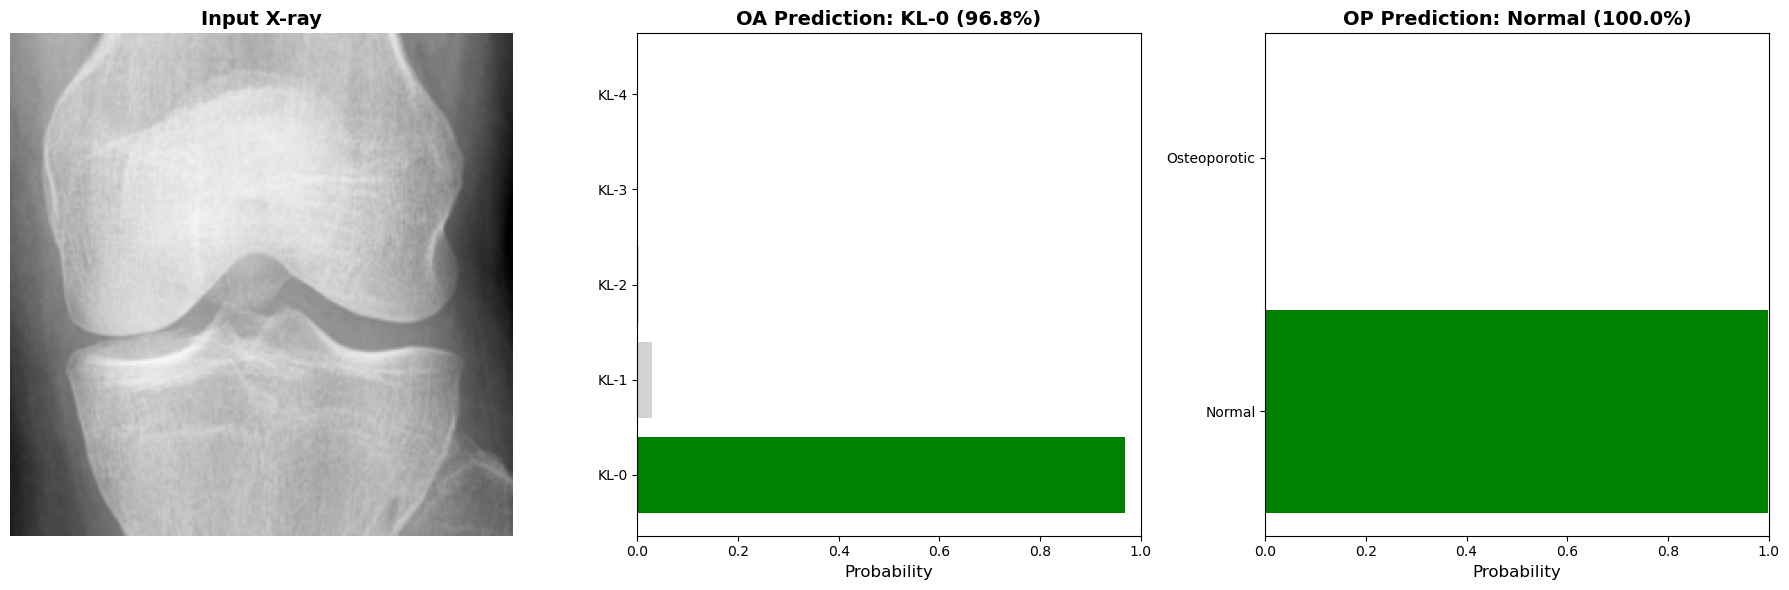


Prediction Results:
  OA Grade: 0 (confidence: 96.8%)
  OP Status: Normal (confidence: 100.0%)


Batch Inference:   0%|          | 0/3 [00:00<?, ?it/s]


BATCH INFERENCE RESULTS (First 20 samples)

Image 1: 9003175L.png
  OA: Grade 0 (96.8%)
  OP: Normal (0.0%)

Image 2: 9003175R.png
  OA: Grade 0 (95.2%)
  OP: Normal (0.1%)

Image 3: 9003316L.png
  OA: Grade 0 (90.1%)
  OP: Normal (0.1%)

Image 4: 9003815L.png
  OA: Grade 0 (94.3%)
  OP: Normal (0.0%)

Image 5: 9003815R.png
  OA: Grade 0 (94.4%)
  OP: Normal (0.0%)

... and 15 more


In [54]:
def predict_single_image(model, image_path, return_visualization=True):
    """Predict OA grade and OP status for a single image"""
    model.eval()
    
    image = Image.open(image_path).convert('RGB')
    image_tensor = val_transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        oa_logits, op_logits = model(image_tensor)
        
        oa_probs = F.softmax(oa_logits, dim=1).squeeze()
        oa_pred = oa_logits.argmax(dim=1).item()
        oa_confidence = oa_probs[oa_pred].item()
        
        op_prob = torch.sigmoid(op_logits).item()
        op_pred = 1 if op_prob > 0.5 else 0
        op_confidence = op_prob if op_pred == 1 else (1 - op_prob)
    
    result = {
        'image_path': image_path,
        'oa_grade': oa_pred,
        'oa_confidence': oa_confidence,
        'oa_probabilities': oa_probs.cpu().numpy(),
        'op_status': 'Osteoporotic' if op_pred == 1 else 'Normal',
        'op_prediction': op_pred,
        'op_confidence': op_confidence,
        'op_probability': op_prob,
    }
    
    if return_visualization:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        axes[0].imshow(image)
        axes[0].axis('off')
        axes[0].set_title('Input X-ray', fontsize=14, fontweight='bold')
        
        grades = ['KL-0', 'KL-1', 'KL-2', 'KL-3', 'KL-4']
        oa_probs_np = oa_probs.cpu().numpy()
        colors = ['green' if i == oa_pred else 'lightgray' for i in range(5)]
        axes[1].barh(grades, oa_probs_np, color=colors)
        axes[1].set_xlabel('Probability', fontsize=12)
        axes[1].set_title(f'OA Prediction: {grades[oa_pred]} ({oa_confidence:.1%})',
                         fontsize=14, fontweight='bold')
        axes[1].set_xlim([0, 1])
        
        op_labels = ['Normal', 'Osteoporotic']
        op_probs_plot = [1 - op_prob, op_prob]
        colors_op = ['green' if i == op_pred else 'lightgray' for i in range(2)]
        axes[2].barh(op_labels, op_probs_plot, color=colors_op)
        axes[2].set_xlabel('Probability', fontsize=12)
        axes[2].set_title(f'OP Prediction: {result["op_status"]} ({op_confidence:.1%})',
                         fontsize=14, fontweight='bold')
        axes[2].set_xlim([0, 1])
        
        plt.tight_layout()
        plt.show()
    
    return result

# Test single image prediction
print("\n" + "="*60)
print("SINGLE IMAGE INFERENCE EXAMPLE")
print("="*60)

sample_image_path = datasets_dict['oa_test'].samples[0][0]
print(f"\nPredicting for: {sample_image_path}")

prediction = predict_single_image(student_model, sample_image_path)

print("\nPrediction Results:")
print(f"  OA Grade: {prediction['oa_grade']} (confidence: {prediction['oa_confidence']:.1%})")
print(f"  OP Status: {prediction['op_status']} (confidence: {prediction['op_confidence']:.1%})")


def predict_batch(model, image_paths, batch_size=8):
    """Predict on multiple images efficiently"""
    model.eval()
    results = []
    
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Batch Inference"):
        batch_paths = image_paths[i:i + batch_size]
        
        images = []
        for path in batch_paths:
            img = Image.open(path).convert('RGB')
            img_tensor = val_transform(img)
            images.append(img_tensor)
        
        images_batch = torch.stack(images).to(device)
        
        with torch.no_grad():
            oa_logits, op_logits = model(images_batch)
            
            oa_probs = F.softmax(oa_logits, dim=1)
            oa_preds = oa_logits.argmax(dim=1)
            
            op_probs = torch.sigmoid(op_logits).squeeze()
            op_preds = (op_probs > 0.5).long()
        
        for j, path in enumerate(batch_paths):
            oa_pred = oa_preds[j].item()
            op_pred = op_preds[j].item() if len(batch_paths) > 1 else op_preds.item()
            op_prob = op_probs[j].item() if len(batch_paths) > 1 else op_probs.item()
            
            results.append({
                'image_path': path,
                'oa_grade': oa_pred,
                'oa_confidence': oa_probs[j][oa_pred].item(),
                'op_status': 'Osteoporotic' if op_pred == 1 else 'Normal',
                'op_probability': op_prob,
            })
    
    return results

# Example: Predict on first 20 test images
sample_paths = [sample[0] for sample in datasets_dict['oa_test'].samples[:20]]
batch_results = predict_batch(student_model, sample_paths)

print("\n" + "="*60)
print("BATCH INFERENCE RESULTS (First 20 samples)")
print("="*60)
for i, result in enumerate(batch_results[:5]):
    print(f"\nImage {i+1}: {os.path.basename(result['image_path'])}")
    print(f"  OA: Grade {result['oa_grade']} ({result['oa_confidence']:.1%})")
    print(f"  OP: {result['op_status']} ({result['op_probability']:.1%})")
print(f"\n... and {len(batch_results)-5} more")

In [58]:
def save_predictions_to_csv(test_results, output_dir):
    """Save all test predictions to CSV files"""
    
    # OA predictions
    oa_df = pd.DataFrame({
        'true_label': test_results['oa']['labels'],
        'predicted_label': test_results['oa']['preds'],
        'prob_KL0': test_results['oa']['probs'][:, 0],
        'prob_KL1': test_results['oa']['probs'][:, 1],
        'prob_KL2': test_results['oa']['probs'][:, 2],
        'prob_KL3': test_results['oa']['probs'][:, 3],
        'prob_KL4': test_results['oa']['probs'][:, 4],
        'correct': np.array(test_results['oa']['labels']) == np.array(test_results['oa']['preds'])
    })
    
    oa_path = os.path.join(output_dir, 'oa_test_predictions.csv')
    oa_df.to_csv(oa_path, index=False)
    print(f"✓ OA predictions saved to {oa_path}")
    
    # OP predictions
    op_df = pd.DataFrame({
        'true_label': test_results['op']['labels'],
        'predicted_label': test_results['op']['preds'],
        'probability_osteoporotic': test_results['op']['probs'],
        'probability_normal': 1 - test_results['op']['probs'],
        'correct': np.array(test_results['op']['labels']) == np.array(test_results['op']['preds'])
    })
    
    op_path = os.path.join(output_dir, 'op_test_predictions.csv')
    op_df.to_csv(op_path, index=False)
    print(f"✓ OP predictions saved to {op_path}")
    
    return oa_df, op_df

# Save predictions
oa_pred_df, op_pred_df = save_predictions_to_csv(
    test_results,
    os.path.join(CONFIG['results_dir'], 'predictions')
)

print("\nSample OA Predictions:")
print(oa_pred_df.head())

print("\nSample OP Predictions:")
print(op_pred_df.head())


def export_model_for_deployment(model, save_dir):
    """Export model in different formats for deployment"""
    
    print("\n" + "="*60)
    print("EXPORTING MODEL FOR DEPLOYMENT")
    print("="*60)
    
    model.eval()
    
    # 1. Save complete model
    complete_path = os.path.join(save_dir, 'student_model_complete.pth')
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_config': {
            'num_oa_classes': CONFIG['num_oa_classes'],
            'num_op_classes': CONFIG['num_op_classes'],
        }
    }, complete_path)
    print(f"\n✓ Complete model saved: {complete_path}")
    
    # 2. Export to TorchScript
    dummy_input = torch.randn(1, 3, CONFIG['img_size'], CONFIG['img_size']).to(device)
    
    try:
        traced_model = torch.jit.trace(model, dummy_input)
        torchscript_path = os.path.join(save_dir, 'student_model_torchscript.pt')
        traced_model.save(torchscript_path)
        print(f"✓ TorchScript model saved: {torchscript_path}")
    except Exception as e:
        print(f"⚠ TorchScript export failed: {e}")
    
    # 3. Save model summary (torchinfo is optional)
    summary_path = os.path.join(save_dir, 'model_summary.txt')
    with open(summary_path, 'w') as f:
        f.write("="*60 + "\n")
        f.write("STUDENT MULTI-TASK MODEL SUMMARY\n")
        f.write("="*60 + "\n\n")
        
        try:
            from torchinfo import summary
            model_summary = summary(model, input_size=(1, 3, CONFIG['img_size'], CONFIG['img_size']))
            f.write(str(model_summary))
            print(f"✓ Detailed model summary saved: {summary_path}")
        except ImportError:
            # Fallback: Basic summary without torchinfo
            f.write("(torchinfo not installed, using basic summary)\n\n")
            total_params = sum(p.numel() for p in model.parameters())
            trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
            f.write(f"Total Parameters: {total_params:,}\n")
            f.write(f"Trainable Parameters: {trainable_params:,}\n")
            f.write(f"\nModel Architecture:\n{str(model)}\n")
            print(f"✓ Basic model summary saved: {summary_path} (torchinfo not available)")
    
    print("\nDeployment files ready!")
    print("Use 'student_model_complete.pth' for PyTorch inference")
    print("Use 'student_model_torchscript.pt' for production deployment")

# Export model
export_model_for_deployment(
    student_model,
    os.path.join(CONFIG['checkpoint_dir'], 'student')
)

✓ OA predictions saved to ./results/predictions/oa_test_predictions.csv
✓ OP predictions saved to ./results/predictions/op_test_predictions.csv

Sample OA Predictions:
   true_label  predicted_label  prob_KL0  prob_KL1  prob_KL2  prob_KL3  \
0           0                0  0.967953  0.029523  0.002518  0.000006   
1           0                0  0.952462  0.042806  0.004713  0.000019   
2           0                0  0.901110  0.085949  0.012896  0.000045   
3           0                0  0.942630  0.051641  0.005711  0.000018   
4           0                0  0.943607  0.050478  0.005892  0.000023   

       prob_KL4  correct  
0  1.379054e-08     True  
1  8.938756e-08     True  
2  1.989638e-07     True  
3  7.363226e-08     True  
4  1.094979e-07     True  

Sample OP Predictions:
   true_label  predicted_label  probability_osteoporotic  probability_normal  \
0         0.0                0                  0.072995            0.927005   
1         0.0                0           

In [59]:
inference_script = '''#!/usr/bin/env python3
"""
Standalone Inference Script for Multi-Task Medical Imaging Model

Usage:
    python inference.py --image path/to/xray.png
    python inference.py --batch path/to/folder/
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import argparse
import json
from pathlib import Path

# Model definition (copy from notebook)
class CBAM(nn.Module):
    # ... (copy CBAM definition)
    pass

class StudentMultiTaskModel(nn.Module):
    # ... (copy StudentMultiTaskModel definition)
    pass

def load_model(checkpoint_path, device='cpu'):
    """Load trained model"""
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    model = StudentMultiTaskModel(
        num_oa_classes=5,
        num_op_classes=1
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    return model

def predict(model, image_path, device='cpu'):
    """Predict on single image"""
    transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                           std=[0.229, 0.224, 0.225]),
    ])
    
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    with torch.no_grad():
        oa_logits, op_logits = model(image_tensor)
        
        oa_probs = F.softmax(oa_logits, dim=1).squeeze()
        oa_pred = oa_logits.argmax(dim=1).item()
        
        op_prob = torch.sigmoid(op_logits).item()
        op_pred = 1 if op_prob > 0.5 else 0
    
    return {
        'oa_grade': oa_pred,
        'oa_confidence': oa_probs[oa_pred].item(),
        'op_status': 'Osteoporotic' if op_pred == 1 else 'Normal',
        'op_confidence': op_prob if op_pred == 1 else (1 - op_prob),
    }

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument('--image', type=str, required=True)
    parser.add_argument('--checkpoint', type=str, 
                       default='checkpoints/student/student_best.pth')
    parser.add_argument('--device', type=str, default='cpu')
    args = parser.parse_args()
    
    # Load model
    print(f"Loading model from {args.checkpoint}...")
    model = load_model(args.checkpoint, args.device)
    
    # Predict
    print(f"Predicting for {args.image}...")
    result = predict(model, args.image, args.device)
    
    # Display results
    print("\\n" + "="*50)
    print("PREDICTION RESULTS")
    print("="*50)
    print(f"OA Grade: {result['oa_grade']} (confidence: {result['oa_confidence']:.1%})")
    print(f"OP Status: {result['op_status']} (confidence: {result['op_confidence']:.1%})")
    print("="*50)
    
    # Save to JSON
    output_path = Path(args.image).stem + '_prediction.json'
    with open(output_path, 'w') as f:
        json.dump(result, f, indent=2)
    print(f"\\nResults saved to {output_path}")

if __name__ == '__main__':
    main()
'''

# Save inference script
script_path = os.path.join(CONFIG['results_dir'], 'inference.py')
with open(script_path, 'w') as f:
    f.write(inference_script)

print(f"✓ Standalone inference script saved to {script_path}")
print("\nUsage:")
print(f"  python {script_path} --image path/to/xray.png")


def generate_final_report(test_results, checkpoint, config):
    """Generate comprehensive final report"""
    
    report = f"""
{'='*80}
MULTI-TASK MEDICAL IMAGING: FINAL REPORT
{'='*80}

PROJECT OVERVIEW
----------------
Task 1: Osteoarthritis (OA) - KL Grading (5-class classification)
Task 2: Osteoporosis (OP) - Binary classification

TRAINING CONFIGURATION
----------------------
Model: EfficientNet-B3 with CBAM attention
Optimizer: AdamW with PCGrad
Knowledge Distillation Temperature: {config['temperature']}
Batch Size: {config['batch_size']}
Learning Rate: {config['learning_rate']}
Total Epochs: {checkpoint['epoch'] + 1}

VALIDATION SET RESULTS (Best Model)
-----------------------------------
OA Task:
  - Accuracy: {checkpoint['val_metrics']['oa_acc']:.4f}
  - QWK: {checkpoint['val_metrics']['oa_qwk']:.4f}
  - Loss: {checkpoint['val_metrics']['oa_loss']:.4f}

OP Task:
  - Accuracy: {checkpoint['val_metrics']['op_acc']:.4f}
  - AUC-ROC: {checkpoint['val_metrics']['op_auc']:.4f}
  - F1-Score: {checkpoint['val_metrics']['op_f1']:.4f}
  - Loss: {checkpoint['val_metrics']['op_loss']:.4f}

TEST SET RESULTS (Final Evaluation)
-----------------------------------
OA Task:
  - Accuracy: {test_results['oa']['metrics']['accuracy']:.4f}
  - QWK: {test_results['oa']['metrics']['qwk']:.4f}
  - Macro F1: {test_results['oa']['metrics']['macro_f1']:.4f}
  - Total Samples: {len(test_results['oa']['labels'])}

OP Task:
  - Accuracy: {test_results['op']['metrics']['accuracy']:.4f}
  - AUC-ROC: {test_results['op']['metrics']['auc']:.4f}
  - F1-Score: {test_results['op']['metrics']['f1']:.4f}
  - Total Samples: {len(test_results['op']['labels'])}

DEPLOYMENT READY
----------------
✓ Model exported in multiple formats
✓ Inference scripts created
✓ Complete documentation available

{'='*80}
TRAINING COMPLETED SUCCESSFULLY
{'='*80}
"""
    
    return report

# Generate and save report
final_report = generate_final_report(test_results, checkpoint, CONFIG)

report_path = os.path.join(CONFIG['results_dir'], 'FINAL_REPORT.txt')
with open(report_path, 'w') as f:
    f.write(final_report)

print(final_report)
print(f"\n✓ Final report saved to {report_path}")

✓ Standalone inference script saved to ./results/inference.py

Usage:
  python ./results/inference.py --image path/to/xray.png

MULTI-TASK MEDICAL IMAGING: FINAL REPORT

PROJECT OVERVIEW
----------------
Task 1: Osteoarthritis (OA) - KL Grading (5-class classification)
Task 2: Osteoporosis (OP) - Binary classification

TRAINING CONFIGURATION
----------------------
Model: EfficientNet-B3 with CBAM attention
Optimizer: AdamW with PCGrad
Knowledge Distillation Temperature: 3.0
Batch Size: 8
Learning Rate: 0.0001
Total Epochs: 33

VALIDATION SET RESULTS (Best Model)
-----------------------------------
OA Task:
  - Accuracy: 0.6126
  - QWK: 0.7443
  - Loss: 1.0222

OP Task:
  - Accuracy: 0.9404
  - AUC-ROC: 0.9758
  - F1-Score: 0.9402
  - Loss: 0.1820

TEST SET RESULTS (Final Evaluation)
-----------------------------------
OA Task:
  - Accuracy: 0.6262
  - QWK: 0.7508
  - Macro F1: 0.5761
  - Total Samples: 1656

OP Task:
  - Accuracy: 0.9241
  - AUC-ROC: 0.9707
  - F1-Score: 0.9244
  - Tot

In [60]:
print("\n" + "="*80)
print("RESEARCH SUMMARY STATISTICS")
print("="*80)

# Calculate additional statistics
print("\nDataset Statistics:")
print(f"  OA Training samples: {len(datasets_dict['oa_train'])}")
print(f"  OA Validation samples: {len(datasets_dict['oa_val'])}")
print(f"  OA Test samples: {len(datasets_dict['oa_test'])}")
print(f"  OP Training samples: {len(datasets_dict['op_train'])}")
print(f"  OP Validation samples: {len(datasets_dict['op_val'])}")
print(f"  OP Test samples: {len(datasets_dict['op_test'])}")

print("\nModel Parameters:")
total_params = sum(p.numel() for p in student_model.parameters())
trainable_params = sum(p.numel() for p in student_model.parameters() if p.requires_grad)
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

print("\nTraining Summary:")
print(f"  Total epochs trained: {checkpoint['epoch'] + 1}")
print(f"  Best epoch: {checkpoint['epoch'] + 1}")
print(f"  Best combined metric: {(checkpoint['val_metrics']['oa_qwk'] + checkpoint['val_metrics']['op_auc'])/2:.4f}")

print("\nTest Set Performance Summary:")
print(f"  OA QWK: {test_results['oa']['metrics']['qwk']:.4f}")
print(f"  OP AUC: {test_results['op']['metrics']['auc']:.4f}")
print(f"  Combined metric: {(test_results['oa']['metrics']['qwk'] + test_results['op']['metrics']['auc'])/2:.4f}")

print("\n" + "="*80)
print("✅ ALL ANALYSIS COMPLETE")
print("="*80)


RESEARCH SUMMARY STATISTICS

Dataset Statistics:
  OA Training samples: 5778
  OA Validation samples: 826
  OA Test samples: 1656
  OP Training samples: 1101
  OP Validation samples: 235
  OP Test samples: 237

Model Parameters:
  Total parameters: 12,829,328
  Trainable parameters: 12,829,328

Training Summary:
  Total epochs trained: 33
  Best epoch: 33
  Best combined metric: 0.8601

Test Set Performance Summary:
  OA QWK: 0.7508
  OP AUC: 0.9707
  Combined metric: 0.8608

✅ ALL ANALYSIS COMPLETE
